6133-010402D Асташин С.В.

In [23]:
# проверяем GPU и компилятор

!nvidia-smi
!nvcc --version

Mon Apr  6 20:35:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%%writefile vector_sum.cu
#include <iostream>
#include <vector>
#include <random>
#include <chrono>
#include <fstream>
#include <iomanip>
#include <cuda_runtime.h>

#define CUDA_CHECK(call)                                                   \
do {                                                                       \
    cudaError_t err = call;                                                \
    if (err != cudaSuccess) {                                              \
        std::cerr << "CUDA error: " << cudaGetErrorString(err)             \
                  << " | file: " << __FILE__                               \
                  << " | line: " << __LINE__ << std::endl;                 \
        exit(EXIT_FAILURE);                                                \
    }                                                                      \
} while (0)


// Последовательное суммирование на CPU

long long cpu_sum(const std::vector<long long>& vec) {
    long long sum = 0;
    for (size_t i = 0; i < vec.size(); ++i) {
        sum += vec[i];
    }
    return sum;
}


// CUDA-ядро редукции суммы
// Каждый поток берет до двух элементов,
// затем внутри блока выполняется редукция.

__global__ void reduce_sum_kernel(const long long* input, long long* output, int n) {
    extern __shared__ long long sdata[];

    unsigned int tid = threadIdx.x;
    unsigned int i = blockIdx.x * blockDim.x * 2 + threadIdx.x;

    long long local_sum = 0;

    if (i < n) {
        local_sum += input[i];
    }
    if (i + blockDim.x < n) {
        local_sum += input[i + blockDim.x];
    }

    sdata[tid] = local_sum;
    __syncthreads();

    // Редукция внутри блока
    for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (tid < s) {
            sdata[tid] += sdata[tid + s];
        }
        __syncthreads();
    }

    if (tid == 0) {
        output[blockIdx.x] = sdata[0];
    }
}


// Функция вычисления суммы на GPU,
// когда данные уже находятся в памяти GPU.
//
// Измеряется только "чистое время ядра":
// без копирования данных CPU <-> GPU.

long long gpu_sum_kernel_only_from_device(const long long* d_input_original, int n, float& kernel_ms) {
    const int threads = 256;

    // Создаем рабочую копию массива на GPU,
    // чтобы не портить исходный массив редукцией.
    long long* d_current = nullptr;
    CUDA_CHECK(cudaMalloc(&d_current, n * sizeof(long long)));
    CUDA_CHECK(cudaMemcpy(d_current, d_input_original, n * sizeof(long long), cudaMemcpyDeviceToDevice));

    int current_n = n;
    long long* d_output = nullptr;

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    // Старт измерения именно вычислительной части
    CUDA_CHECK(cudaEventRecord(start));

    while (current_n > 1) {
        int blocks = (current_n + threads * 2 - 1) / (threads * 2);

        CUDA_CHECK(cudaMalloc(&d_output, blocks * sizeof(long long)));

        reduce_sum_kernel<<<blocks, threads, threads * sizeof(long long)>>>(d_current, d_output, current_n);
        CUDA_CHECK(cudaGetLastError());

        // Ждем завершения текущего ядра
        CUDA_CHECK(cudaDeviceSynchronize());

        CUDA_CHECK(cudaFree(d_current));
        d_current = d_output;
        current_n = blocks;
    }

    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));
    CUDA_CHECK(cudaEventElapsedTime(&kernel_ms, start, stop));

    // Результат переносим обратно на CPU
    // Это уже НЕ входит в kernel_ms
    long long result = 0;
    CUDA_CHECK(cudaMemcpy(&result, d_current, sizeof(long long), cudaMemcpyDeviceToHost));

    CUDA_CHECK(cudaFree(d_current));
    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));

    return result;
}


// Функция вычисления суммы на GPU с измерением
// полного времени:
// 1) выделение памяти,
// 2) копирование CPU -> GPU,
// 3) выполнение ядер,
// 4) копирование результата GPU -> CPU,
// 5) освобождение памяти.
//
// Дополнительно внутри также возвращается kernel_ms,
// то есть "чистое" время выполнения ядер.

long long gpu_sum_total(const std::vector<long long>& h_vec, float& total_ms, float& kernel_ms) {
    const int n = static_cast<int>(h_vec.size());
    const int threads = 256;

    long long* d_input = nullptr;
    long long* d_current = nullptr;
    long long* d_output = nullptr;

    cudaEvent_t total_start, total_stop;
    cudaEvent_t kernel_start, kernel_stop;

    CUDA_CHECK(cudaEventCreate(&total_start));
    CUDA_CHECK(cudaEventCreate(&total_stop));
    CUDA_CHECK(cudaEventCreate(&kernel_start));
    CUDA_CHECK(cudaEventCreate(&kernel_stop));

    // Начинаем измерять полное время GPU
    CUDA_CHECK(cudaEventRecord(total_start));

    // Выделяем память и копируем исходный массив на GPU
    CUDA_CHECK(cudaMalloc(&d_input, n * sizeof(long long)));
    CUDA_CHECK(cudaMemcpy(d_input, h_vec.data(), n * sizeof(long long), cudaMemcpyHostToDevice));

    d_current = d_input;
    int current_n = n;

    // Начинаем измерять только время ядра
    CUDA_CHECK(cudaEventRecord(kernel_start));

    while (current_n > 1) {
        int blocks = (current_n + threads * 2 - 1) / (threads * 2);

        CUDA_CHECK(cudaMalloc(&d_output, blocks * sizeof(long long)));

        reduce_sum_kernel<<<blocks, threads, threads * sizeof(long long)>>>(d_current, d_output, current_n);
        CUDA_CHECK(cudaGetLastError());
        CUDA_CHECK(cudaDeviceSynchronize());

        if (d_current != d_input) {
            CUDA_CHECK(cudaFree(d_current));
        }

        d_current = d_output;
        current_n = blocks;
    }

    CUDA_CHECK(cudaEventRecord(kernel_stop));
    CUDA_CHECK(cudaEventSynchronize(kernel_stop));
    CUDA_CHECK(cudaEventElapsedTime(&kernel_ms, kernel_start, kernel_stop));

    // Копируем итоговую сумму обратно на CPU
    long long result = 0;
    CUDA_CHECK(cudaMemcpy(&result, d_current, sizeof(long long), cudaMemcpyDeviceToHost));

    // Освобождаем память
    if (d_current != d_input) {
        CUDA_CHECK(cudaFree(d_current));
    }
    CUDA_CHECK(cudaFree(d_input));

    // Останавливаем полное время
    CUDA_CHECK(cudaEventRecord(total_stop));
    CUDA_CHECK(cudaEventSynchronize(total_stop));
    CUDA_CHECK(cudaEventElapsedTime(&total_ms, total_start, total_stop));

    CUDA_CHECK(cudaEventDestroy(total_start));
    CUDA_CHECK(cudaEventDestroy(total_stop));
    CUDA_CHECK(cudaEventDestroy(kernel_start));
    CUDA_CHECK(cudaEventDestroy(kernel_stop));

    return result;
}


int main() {
    CUDA_CHECK(cudaFree(0)); // разогрев CUDA-контекста

    std::vector<int> sizes = {1000, 5000, 10000, 50000, 100000, 250000, 500000, 1000000};
    const int repeats = 20;

    std::ofstream csv("results.csv");
    csv << "n,cpu_sum,gpu_sum,cpu_ms,gpu_total_ms,gpu_kernel_ms,speedup_total,speedup_kernel\n";

    std::cout << std::left
              << std::setw(12) << "N"
              << std::setw(18) << "CPU sum"
              << std::setw(18) << "GPU sum"
              << std::setw(14) << "CPU ms"
              << std::setw(16) << "GPU total ms"
              << std::setw(16) << "GPU kernel ms"
              << std::setw(16) << "Speedup total"
              << std::setw(16) << "Speedup kernel"
              << "\n";

    std::cout << std::string(126, '-') << "\n";

    std::mt19937 rng(42);
    std::uniform_int_distribution<int> dist(1, 10);

    for (int n : sizes) {
        std::vector<long long> vec(n);
        for (int i = 0; i < n; ++i) {
            vec[i] = dist(rng);
        }

        // Разогрев GPU

        float warm_total_ms = 0.0f;
        float warm_kernel_ms = 0.0f;
        long long warm_sum = gpu_sum_total(vec, warm_total_ms, warm_kernel_ms);

        // Измерение CPU

        double cpu_total_time = 0.0;
        long long cpu_result = 0;

        for (int r = 0; r < repeats; ++r) {
            auto start = std::chrono::high_resolution_clock::now();
            cpu_result = cpu_sum(vec);
            auto end = std::chrono::high_resolution_clock::now();

            double elapsed = std::chrono::duration<double, std::milli>(end - start).count();
            cpu_total_time += elapsed;
        }

        double cpu_avg_ms = cpu_total_time / repeats;

        // Измерение GPU total

        double gpu_total_time_sum = 0.0;
        double gpu_kernel_time_sum = 0.0;
        long long gpu_result_total = 0;

        for (int r = 0; r < repeats; ++r) {
            float total_ms = 0.0f;
            float kernel_ms = 0.0f;
            gpu_result_total = gpu_sum_total(vec, total_ms, kernel_ms);

            gpu_total_time_sum += total_ms;
            gpu_kernel_time_sum += kernel_ms;
        }

        double gpu_total_avg_ms = gpu_total_time_sum / repeats;
        double gpu_kernel_avg_ms = gpu_kernel_time_sum / repeats;

        // Отдельно измеряем kernel-only,
        // когда массив уже лежит на GPU

        long long* d_vec = nullptr;
        CUDA_CHECK(cudaMalloc(&d_vec, n * sizeof(long long)));
        CUDA_CHECK(cudaMemcpy(d_vec, vec.data(), n * sizeof(long long), cudaMemcpyHostToDevice));

        double kernel_only_sum = 0.0;
        long long gpu_result_kernel_only = 0;

        for (int r = 0; r < repeats; ++r) {
            float kernel_ms = 0.0f;
            gpu_result_kernel_only = gpu_sum_kernel_only_from_device(d_vec, n, kernel_ms);
            kernel_only_sum += kernel_ms;
        }

        CUDA_CHECK(cudaFree(d_vec));

        double gpu_kernel_only_avg_ms = kernel_only_sum / repeats;

        // Проверка корректности
        if (cpu_result != warm_sum || cpu_result != gpu_result_total || cpu_result != gpu_result_kernel_only) {
            std::cerr << "Ошибка: суммы не совпадают для N = " << n << std::endl;
            return 1;
        }

        // Для таблицы используем именно:
        // gpu_total_avg_ms  -> полное время
        // gpu_kernel_only_avg_ms -> чистое время ядра при уже загруженном массиве
        double speedup_total = cpu_avg_ms / gpu_total_avg_ms;
        double speedup_kernel = cpu_avg_ms / gpu_kernel_only_avg_ms;

        std::cout << std::left
                  << std::setw(12) << n
                  << std::setw(18) << cpu_result
                  << std::setw(18) << gpu_result_total
                  << std::setw(14) << std::fixed << std::setprecision(6) << cpu_avg_ms
                  << std::setw(16) << std::fixed << std::setprecision(6) << gpu_total_avg_ms
                  << std::setw(16) << std::fixed << std::setprecision(6) << gpu_kernel_only_avg_ms
                  << std::setw(16) << std::fixed << std::setprecision(3) << speedup_total
                  << std::setw(16) << std::fixed << std::setprecision(3) << speedup_kernel
                  << "\n";

        csv << n << ","
            << cpu_result << ","
            << gpu_result_total << ","
            << cpu_avg_ms << ","
            << gpu_total_avg_ms << ","
            << gpu_kernel_only_avg_ms << ","
            << speedup_total << ","
            << speedup_kernel << "\n";
    }

    csv.close();
    std::cout << "\nРезультаты сохранены в results.csv\n";

    return 0;
}

Overwriting vector_sum.cu


In [25]:
# Компилируем CUDA-программу
!nvcc -O2 -std=c++14 vector_sum.cu -o vector_sum

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [26]:
# Запускаем программу
!./vector_sum

N           CPU sum           GPU sum           CPU ms        GPU total ms    GPU kernel ms   Speedup total   Speedup kernel  
------------------------------------------------------------------------------------------------------------------------------
1000        5477              5477              0.000442      0.180909        0.031406        0.002           0.014           
5000        27591             27591             0.002072      0.189314        0.031147        0.011           0.067           
10000       54634             54634             0.004090      0.203475        0.028418        0.020           0.144           
50000       275581            275581            0.020336      0.288507        0.029379        0.070           0.692           
100000      550829            550829            0.046213      0.418082        0.028914        0.111           1.598           
250000      1375202           1375202           0.108024      0.673290        0.083781        0.160           1

In [27]:
import pandas as pd

df = pd.read_csv("results.csv")

display(df.round({
    "cpu_ms": 6,
    "gpu_total_ms": 6,
    "gpu_kernel_ms": 6,
    "speedup_total": 3,
    "speedup_kernel": 3
}))

,n,cpu_sum,gpu_sum,cpu_ms,gpu_total_ms,gpu_kernel_ms,speedup_total,speedup_kernel
0,1000,5477,5477,0.000442,0.180909,0.031406,0.002,0.014
1,5000,27591,27591,0.002072,0.189314,0.031147,0.011,0.067
2,10000,54634,54634,0.004090,0.203475,0.028418,0.020,0.144
3,50000,275581,275581,0.020336,0.288507,0.029379,0.070,0.692
4,100000,550829,550829,0.046213,0.418082,0.028914,0.111,1.598
5,250000,1375202,1375202,0.108024,0.673290,0.083781,0.160,1.289
6,500000,2749672,2749672,0.225790,1.266290,0.146478,0.178,1.541
7,1000000,5502077,5502077,0.441521,1.978320,0.148157,0.223,2.980


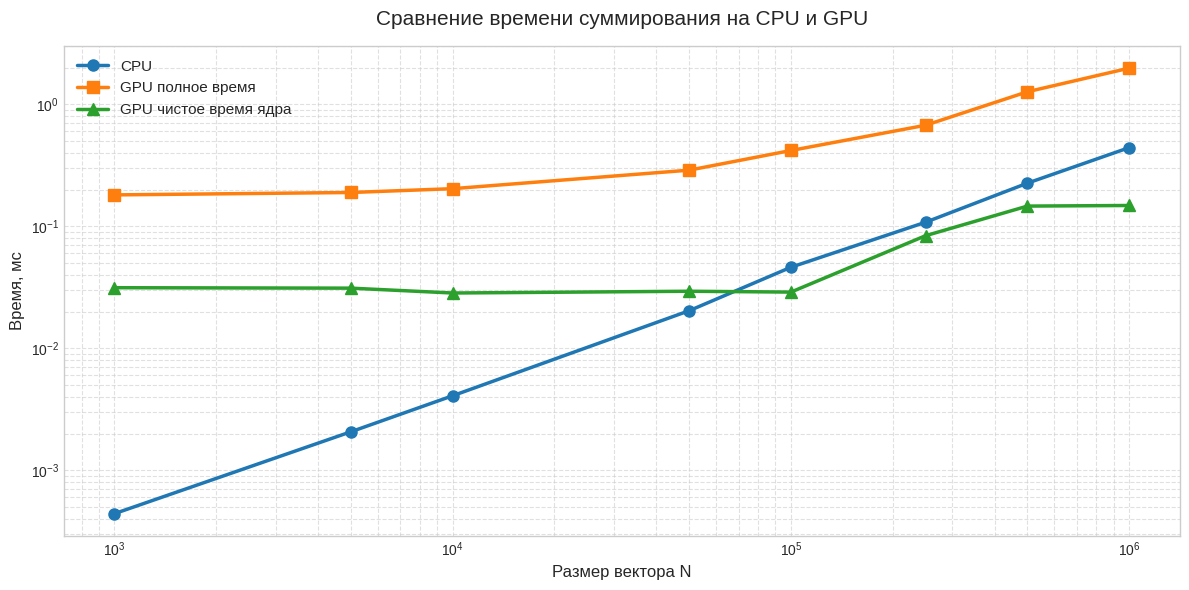

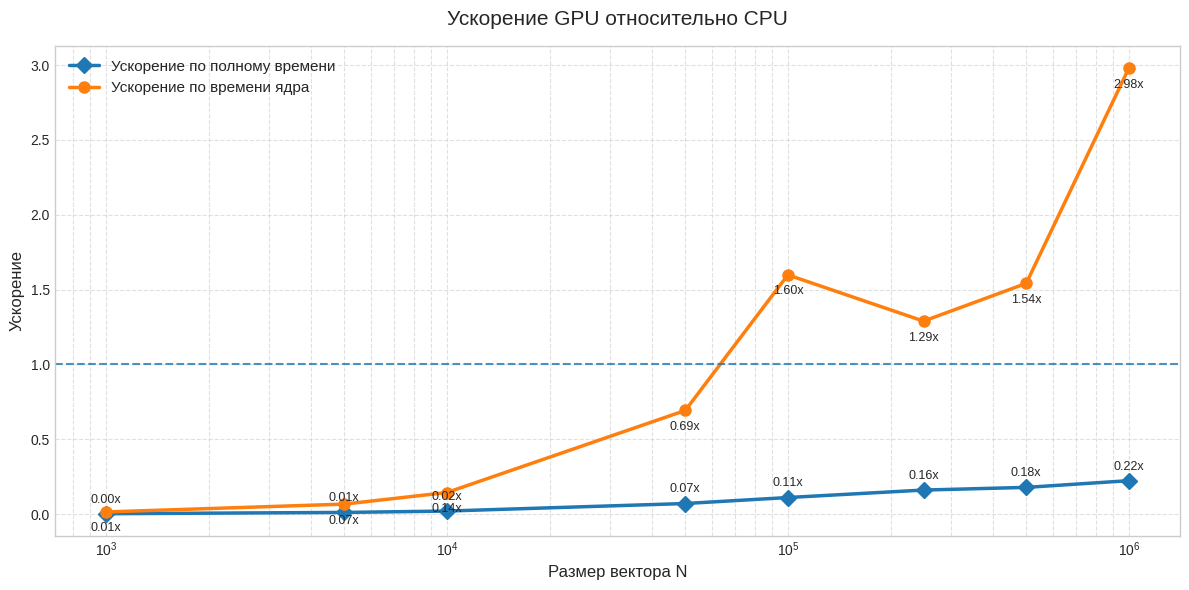

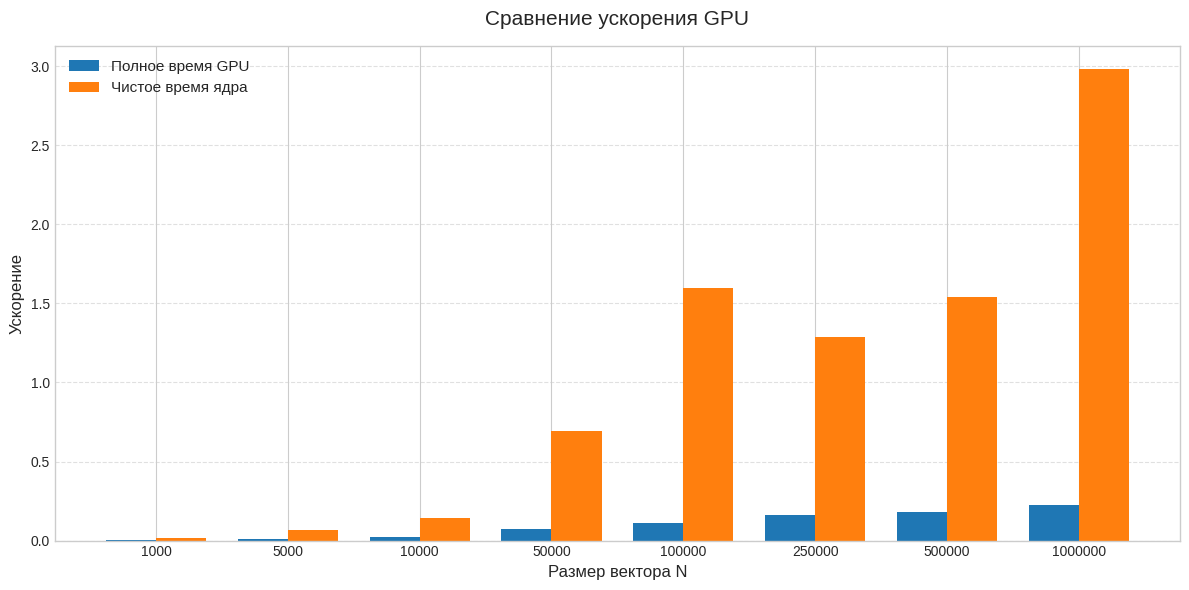

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")

plt.style.use("seaborn-v0_8-whitegrid")

# График 1: CPU vs GPU total vs GPU kernel

plt.figure(figsize=(12, 6))

plt.plot(df["n"], df["cpu_ms"], marker="o", linewidth=2.5, markersize=8, label="CPU")
plt.plot(df["n"], df["gpu_total_ms"], marker="s", linewidth=2.5, markersize=8, label="GPU полное время")
plt.plot(df["n"], df["gpu_kernel_ms"], marker="^", linewidth=2.5, markersize=8, label="GPU чистое время ядра")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Размер вектора N", fontsize=12)
plt.ylabel("Время, мс", fontsize=12)
plt.title("Сравнение времени суммирования на CPU и GPU", fontsize=15, pad=15)
plt.legend(fontsize=11)
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("time_comparison_full_vs_kernel.png", dpi=300, bbox_inches="tight")
plt.show()


# График 2: ускорение

plt.figure(figsize=(12, 6))

plt.plot(df["n"], df["speedup_total"], marker="D", linewidth=2.5, markersize=8, label="Ускорение по полному времени")
plt.plot(df["n"], df["speedup_kernel"], marker="o", linewidth=2.5, markersize=8, label="Ускорение по времени ядра")

plt.xscale("log")
plt.axhline(y=1.0, linestyle="--", linewidth=1.5, alpha=0.8)

plt.xlabel("Размер вектора N", fontsize=12)
plt.ylabel("Ускорение", fontsize=12)
plt.title("Ускорение GPU относительно CPU", fontsize=15, pad=15)
plt.legend(fontsize=11)
plt.grid(True, which="both", linestyle="--", alpha=0.6)

for x, y in zip(df["n"], df["speedup_total"]):
    plt.annotate(f"{y:.2f}x", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)

for x, y in zip(df["n"], df["speedup_kernel"]):
    plt.annotate(f"{y:.2f}x", (x, y), textcoords="offset points", xytext=(0, -14), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("speedup_full_vs_kernel.png", dpi=300, bbox_inches="tight")
plt.show()


# График 3: столбики ускорения

plt.figure(figsize=(12, 6))

x = range(len(df))
labels = df["n"].astype(str)

width = 0.38

plt.bar([i - width/2 for i in x], df["speedup_total"], width=width, label="Полное время GPU")
plt.bar([i + width/2 for i in x], df["speedup_kernel"], width=width, label="Чистое время ядра")

plt.xticks(list(x), labels)
plt.xlabel("Размер вектора N", fontsize=12)
plt.ylabel("Ускорение", fontsize=12)
plt.title("Сравнение ускорения GPU", fontsize=15, pad=15)
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("speedup_bar_full_vs_kernel.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
from google.colab import files

files.download("results.csv")
files.download("time_comparison_full_vs_kernel.png")
files.download("speedup_full_vs_kernel.png")
files.download("speedup_bar_full_vs_kernel.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>